# pYtag puncta quantification 

This notebook implements the following:

1. **Global per-image normalization** using the full image:
   
`norm = (img - P25(img)) / IQR(img)` where `IQR = P75 - P25`.

2. **Per-branch puncta pixels** using either:
   - `median(branch) + k * IQR(branch)` (default `k=4`), or
   - a high percentile (default `99th`).

3. **Per-branch readouts**
   - **`n_puncta`** = number of distinct puncta (local maxima separated by a minimum distance).
   - **`puncta_mean_intensity`** = mean normalized intensity of puncta pixels.

There are two parts:
- **Exploration / QC** (plots, parameter tuning on a single sample).
- **Batch processing** (loop over many image/mask pairs, writing a long-form results table).

In [ ]:
# If running in a fresh environment, install dependencies as needed:
# !pip install numpy scipy pandas scikit-image tifffile matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve()))

# ---- SET THIS TO YOUR LOCAL DATA ROOT ----
data_root = "/path/to/data"
# ------------------------------------------

from pytag_puncta_quantification_refactored import (
    load_tiff_stack,
    filter_mask_to_metameres,
    QuantParams,
    quantify_puncta_per_branch,
)

## 1) Load one image + mask (and filter the mask to real branches)

- load image + mask
- filter out spurious labeled regions via the *metamere lookup CSV* (so only real branches remain)


In [ ]:
# ---- EDIT THESE ----
month = "2510"
mutant_or_ctl_images = "MUTANT"
mutant_or_ctl = "Mutant"   # e.g. "Control" or "Mutant" / "BnlHet"
Embryo_num = "Embryo6"
Tr = "Tr9bottom"
extra = "_Tr6top"
stage13 = "_"

image_path = f"{data_root}/2025/{month}/PYTAG_{mutant_or_ctl_images}_ANALYSIS/{Embryo_num}/{Embryo_num}{stage13}{Tr}{extra}_pYtag_orig.tif"
mask_path  = f"{data_root}/2025/{month}/PYTAG_{mutant_or_ctl_images}_ANALYSIS/{Embryo_num}/Napari/NAPARI_notrunklabeled_{Embryo_num}{stage13}{Tr}{extra}_Imaris_mask_FILL_HOLES.tif"

# If your lookup CSV is genotype-specific, keep this pattern; otherwise set a fixed CSV path.
filter_csv = f"{data_root}/2025/{month}/pYtag_metamere_lookup_2510_{mutant_or_ctl}.csv"

# In your notebook you used this rule (keep it if it matches your experiment):
Half = "Posterior" if Tr == "Tr9bottom" else "Anterior"
# ---------------------

img = load_tiff_stack(image_path)
mask_unfiltered = load_tiff_stack(mask_path)
mask = filter_mask_to_metameres(mask_unfiltered, filter_csv, Embryo_num, Half)

print("img:", img.shape, img.dtype, "min/max:", float(np.min(img)), float(np.max(img)))
print("mask:", mask.shape, mask.dtype, "n labels (excl 0):", int(len(np.unique(mask)) - 1))

## 2) Quick visualization (max-intensity projections)

We plot:
- normalized image max projection
- branch mask max projection
- puncta pixels + peaks overlays (after quantification)


In [24]:
def mip(vol):
    return np.max(vol, axis=0)

def show_mips(img2d, mask2d=None, puncta2d=None, peaks2d=None, title=""):
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.imshow(img2d, cmap="gray")
    if mask2d is not None:
        ax.contour(mask2d > 0, levels=[0.5], linewidths=0.8)
    if puncta2d is not None:
        ax.imshow(np.ma.masked_where(~puncta2d, puncta2d), alpha=0.75)
    if peaks2d is not None:
        yy, xx = np.where(peaks2d)
        ax.scatter(xx, yy, s=2, marker="o")
    ax.set_title(title)
    ax.axis("off")
    plt.show()


In [29]:
# Choose one parameter set for QC
params = QuantParams(
    thr_mode="median_k_iqr",  # "percentile" or "median_k_iqr"
    thr_k=25.0,
    thr_percentile=99.98,
    min_puncta_voxels=3,
    peak_rxy=2,
    peak_rz=1,
)

df, meta, inter = quantify_puncta_per_branch(img, mask, params=params, return_intermediates=True)
df.head()


,branch_id,branch_voxels,puncta_voxels,puncta_fraction,puncta_mean_intensity,n_puncta,thr
0,1,92823,2443,0.026319,31.135195,28,25.333333
1,2,75369,4971,0.065955,29.515541,31,25.333333
2,3,73842,683,0.009249,34.572193,5,25.333333
3,6,62633,41,0.000655,31.065041,1,25.333333


P25 = 5
P75 = 26
Median = 12
IQR = 21
Median + 25*IQR = 537
P100 = 595


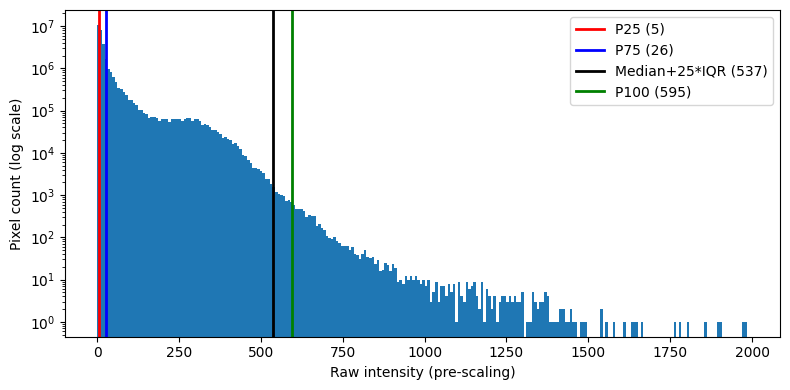

In [30]:
# Histogram of raw (pre-scaling) intensities with key quantiles / thresholds
vals = img.astype(np.float32).ravel()
vals = vals[np.isfinite(vals)]

# Percentiles are computed on the full image (same universe used for global normalization)
p25, p75, med, p99 = np.percentile(vals, [25, 75, 50, params.thr_percentile])
iqr = p75 - p25
thr_med_4iqr = med + params.thr_k * iqr

print(f"P25 = {p25:.3g}")
print(f"P75 = {p75:.3g}")
print(f"Median = {med:.3g}")
print(f"IQR = {iqr:.3g}")
print(f"Median + {params.thr_k:.2g}*IQR = {thr_med_4iqr:.3g}")
print(f"P{params.thr_percentile:.3g} = {p99:.3g}")


fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(vals, bins=256)
ax.set_yscale("log")
ax.set_xlabel("Raw intensity (pre-scaling)")
ax.set_ylabel("Pixel count (log scale)")

ax.axvline(p25, linewidth=2, label=f"P25 ({p25:.3g})",color='r')
ax.axvline(p75, linewidth=2, label=f"P75 ({p75:.3g})",color='b')
ax.axvline(thr_med_4iqr, linewidth=2, label=f"Median+{params.thr_k:.2g}*IQR ({thr_med_4iqr:.3g})",color='black')
ax.axvline(p99, linewidth=2, label=f"P{params.thr_percentile:.3g} ({p99:.3g})",color='g')

ax.legend()
fig.tight_layout()
plt.show()

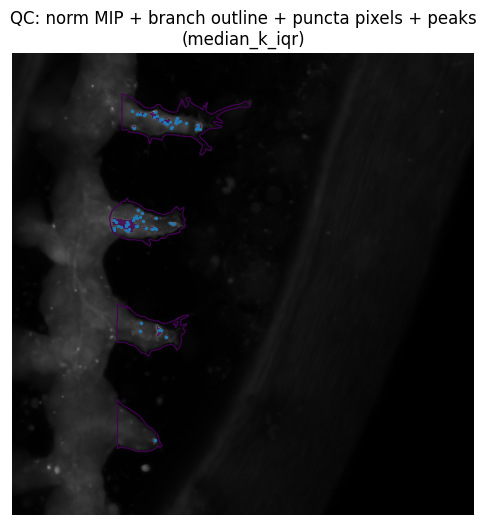

In [31]:
norm_img = inter["norm_img"]
puncta_mask = inter["puncta_mask"]
peaks_df = inter["peaks_df"]

# Make a simple 2D peaks overlay for the MIP
peaks_mip = np.zeros_like(mip(norm_img), dtype=bool)
for _, r in peaks_df.iterrows():
    z, y, x = int(r["z"]), int(r["y"]), int(r["x"])
    peaks_mip[y, x] = True

show_mips(
    mip(norm_img),
    mask2d=mip(mask),
    puncta2d=mip(puncta_mask),
    peaks2d=peaks_mip,
    title=f"QC: norm MIP + branch outline + puncta pixels + peaks\n({params.thr_mode})",
)


In [32]:
# save MIP as a tiff file
import tifffile as tiff

# --- Generate fresh MIPs (do NOT reuse variable names) ---
img_mip = mip(norm_img)
mask_mip = mip(mask)
puncta_mip = mip(puncta_mask)

# peaks_mip was already created above — do not overwrite it
peaks_mip_export = peaks_mip.copy()

# --- Create export-formatted copies ---
img_export     = img_mip.astype(np.float32)
mask_export    = mask_mip.astype(np.uint8)
puncta_export  = puncta_mip.astype(np.uint8)
peaks_export   = peaks_mip_export.astype(np.uint8)

# --- Stack as channels (C, Y, X) ---
qc_stack = np.stack(
    [img_export, mask_export, puncta_export, peaks_export],
    axis=0
)

tiff.imwrite(
    "Representative_Images/MUTANT_Embryo6_Posterior_qc_multichannel_25IQR_Method.tif",
    qc_stack,
    imagej=True,
)

## 3) Compare the two thresholding strategies on this one sample

Both:
- `median + k*IQR`
- `99th percentile`

In [91]:
params_a = QuantParams(thr_mode="median_k_iqr", thr_k=params.thr_k, min_puncta_voxels=params.min_puncta_voxels, peak_rxy=params.peak_rxy, peak_rz=params.peak_rz)
params_b = QuantParams(thr_mode="percentile", thr_percentile=params.thr_percentile, min_puncta_voxels=params.min_puncta_voxels, peak_rxy=params.peak_rxy, peak_rz=params.peak_rz)

df_a, _, _ = quantify_puncta_per_branch(img, mask, params=params_a, return_intermediates=False)
df_b, _, _ = quantify_puncta_per_branch(img, mask, params=params_b, return_intermediates=False)

df_a = df_a.assign(strategy=f"median+{params.thr_k}*IQR")
df_b = df_b.assign(strategy=f"P{params.thr_percentile}")

cmp = pd.concat([df_a, df_b], ignore_index=True)
cmp.head()


,branch_id,branch_voxels,puncta_voxels,puncta_fraction,puncta_mean_intensity,n_puncta,thr,strategy
0,2,167751,954,0.005687,39.162285,12,25.272727,median+25.0*IQR
1,3,122782,476,0.003877,32.278454,9,25.272727,median+25.0*IQR
2,4,104051,537,0.005161,34.834606,8,25.272727,median+25.0*IQR
3,5,88067,331,0.003759,34.230705,6,25.272727,median+25.0*IQR
4,2,167751,1872,0.011159,30.682985,21,19.909090,P99.98


In [92]:
cmp

,branch_id,branch_voxels,puncta_voxels,puncta_fraction,puncta_mean_intensity,n_puncta,thr,strategy
0,2,167751,954,0.005687,39.162285,12,25.272727,median+25.0*IQR
1,3,122782,476,0.003877,32.278454,9,25.272727,median+25.0*IQR
2,4,104051,537,0.005161,34.834606,8,25.272727,median+25.0*IQR
3,5,88067,331,0.003759,34.230705,6,25.272727,median+25.0*IQR
4,2,167751,1872,0.011159,30.682985,21,19.909090,P99.98
5,3,122782,985,0.008022,27.002859,13,19.909090,P99.98
6,4,104051,1028,0.009880,28.835871,12,19.909090,P99.98
7,5,88067,933,0.010594,26.361397,16,19.909090,P99.98


## 4) Batch processing

This code:
- finds mask files
- infers the matching image path
- parses metadata from the filenames
- filters the mask via the metamere lookup CSV
- runs quantification and outputs a long-form CSV (one row per branch)


In [ ]:
from pathlib import Path
import re
import pandas as pd

# ---------------------------------------------------------
# 1️⃣ METADATA PARSING
# ---------------------------------------------------------

def infer_metadata_from_paths(image_path: Path, mask_path: Path) -> dict:
    """
    Extract embryo number and embryo half from filename.
    """

    name = image_path.stem

    # Extract embryo number (e.g. Embryo1)
    m_emb = re.search(r"(Embryo\d+)", name)
    embryo = m_emb.group(1) if m_emb else None

    # Determine anterior vs posterior
    if "Tr9bottom" in name:
        half = "Posterior"
    else:
        half = "Anterior"

    # Determine genotype from folder structure
    genotype = "Mutant"
    for part in image_path.parts:
        if "Control" in part:
            genotype = "Control"
        if "Mutant" in part:
            genotype = "Mutant"

    return {
        "Embryo_num": embryo,
        "Half": half,
        "genotype": genotype
    }


# ---------------------------------------------------------
# 2️⃣ BUILD IMAGE / MASK PAIRS
# ---------------------------------------------------------

def build_pairs(base: Path) -> list[tuple[Path, Path, str]]:
    pairs = []

    for mask_path in base.rglob("NAPARI_notrunklabeled*Imaris_mask_FILL_HOLES.tif"):

        embryo_dir = mask_path.parent.parent  # Napari → Embryo folder

        image_name = mask_path.name.replace(
            "_Imaris_mask_FILL_HOLES.tif", "_pYtag_orig.tif"
        )
        image_name = image_name.replace("NAPARI_notrunklabeled_", "")
        image_path = embryo_dir / image_name

        if image_path.exists():
            sample_id = image_path.stem.replace("_pYtag_orig", "")
            pairs.append((image_path, mask_path, sample_id))

    return pairs


# ---------------------------------------------------------
# 3️⃣ ASSIGN METAMERES PER BRANCH
# ---------------------------------------------------------

def assign_metameres(df, lookup_csv, embryo, half):
    """
    Map branch_id → biological metamere using lookup CSV.
    Remove non-branch labels automatically.
    """

    lookup = pd.read_csv(lookup_csv)

    embryo_int = int(embryo.replace("Embryo", ""))

    row = lookup[
        (lookup["Embryo"] == embryo_int) &
        (lookup["Half"] == half)
    ]

    if row.empty:
        print(f"WARNING: No lookup entry for {embryo} {half}")
        df["Metamere"] = None
        return df

    row = row.iloc[0]

    # Build label → metamere dictionary
    label_to_meta = {}

    for i in range(1, 6):
        metamere = row[f"Metamere{i}"]
        label = row[f"Label{i}"]

        # Skip empty entries
        if pd.isna(label) or pd.isna(metamere):
            continue

        label_to_meta[int(label)] = metamere

    # Ensure types match
    df["branch_id"] = df["branch_id"].astype(int)

    df["Metamere"] = df["branch_id"].map(label_to_meta)

    # Remove junk segmented regions
    df = df[df["Metamere"].notna()].copy()

    return df


# ---------------------------------------------------------
# 4️⃣ BATCH QUANTIFICATION
# ---------------------------------------------------------

def batch_quantify(pairs, params_list):

    rows = []

    for image_path, mask_path, sample_id in pairs:

        img = load_tiff_stack(str(image_path))
        mask_raw = load_tiff_stack(str(mask_path))

        meta = infer_metadata_from_paths(image_path, mask_path)

        lookup_csv = (
            f"{data_root}/2025/2510/"
            f"pYtag_metamere_lookup_2510_{meta['genotype']}.csv"
        )

        # Optional: still filter mask if you want
        mask = filter_mask_to_metameres(
            mask_raw,
            lookup_csv,
            meta["Embryo_num"],
            meta["Half"]
        )

        for params in params_list:

            df, _, _ = quantify_puncta_per_branch(
                img,
                mask,
                params=params,
                return_intermediates=False
            )

            # 🔥 CRITICAL STEP: assign biological identity per branch
            df = assign_metameres(
                df,
                lookup_csv,
                meta["Embryo_num"],
                meta["Half"]
            )

            # Attach metadata
            df["sample_id"] = sample_id
            df["genotype"] = meta["genotype"]
            df["Embryo_num"] = meta["Embryo_num"]
            df["Half"] = meta["Half"]
            df["image_path"] = str(image_path)
            df["mask_path"] = str(mask_path)

            # Label quantification strategy
            if params.thr_mode == "median_k_iqr":
                strat = f"median+{params.thr_k}*IQR"
            else:
                strat = f"P{params.thr_percentile}"

            df["strategy"] = strat

            rows.append(df)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


# ---------------------------------------------------------
# 5️⃣ RUN
# ---------------------------------------------------------

base = Path(f"{data_root}/2025/2510/PYTAG_MUTANT_ANALYSIS")

pairs = build_pairs(base)
print("Found pairs:", len(pairs))

params_list = [
    QuantParams(thr_mode="median_k_iqr", thr_k=25.0,
                min_puncta_voxels=3, peak_rxy=2, peak_rz=1),
    QuantParams(thr_mode="percentile", thr_percentile=99.98,
                min_puncta_voxels=3, peak_rxy=2, peak_rz=1),
]

results_df = batch_quantify(pairs, params_list)

results_df.head()

In [ ]:
# Save results (long-form table: one row per branch)
results_df.to_csv(f"pYtag_mutant_refactored_results/MUTANT_pytag_puncta_branch_metrics_refactored_25IQR.csv", index=False)
print("Wrote MUTANT_pytag_puncta_branch_metrics_refactored_25IQR.csv")